In [ ]:
# Ref: https://www.kaggle.com/code/ahnc2171/cmi-nnn/notebook
!pip install tqdm scipy --quiet

import os
import random
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils import clip_grad_norm_

from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
from copy import deepcopy
#import kaggle_evaluation.cmi_inference_server
from scipy.spatial.transform import Rotation as R

import warnings
warnings.filterwarnings("ignore")


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

device = 'mps'
print("Device:", device)

Device: mps


In [3]:
# ============================================================
# 1. ĐỌC DỮ LIỆU
# ============================================================
DATA_DIR = '/Users/ashhadulislam/projects/general_data/CMI/ Detect Behavior with Sensor Data/cmi-detect-behavior-with-sensor-data/'

train_path      = os.path.join(DATA_DIR, "train.csv")
test_path       = os.path.join(DATA_DIR, "test.csv")          # không dùng trong train
train_demo_path = os.path.join(DATA_DIR, "train_demographics.csv")
test_demo_path  = os.path.join(DATA_DIR, "test_demographics.csv")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
train_demo = pd.read_csv(train_demo_path)
test_demo  = pd.read_csv(test_demo_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train demo :", train_demo.shape)

Train shape: (574945, 341)
Test shape : (107, 336)
Train demo : (81, 8)


In [4]:
# ============================================================
# 2. MERGE DEMOGRAPHICS ĐỂ LẤY HANDEDNESS
# ============================================================
train_df = train_df.merge(train_demo, on="subject", how="left")

In [5]:
# ============================================================
# 3. TIỀN XỬ LÝ CHUẨN CMI: IMU + ToF + THERMAL
# ============================================================

TOF_COLS = [c for c in train_df.columns if c.startswith("tof_")]
THM_COLS = [c for c in train_df.columns if c.startswith("thm_")]

print("Num ToF cols:", len(TOF_COLS))
print("Num Thermal cols:", len(THM_COLS))

IMU_BASE_COLS = [
    "acc_x","acc_y","acc_z",
    "rot_w","rot_x","rot_y","rot_z"
]

IMU_FEATURE_NAMES = [
    "acc_x", "acc_y", "acc_z",
    "rot_6d_0", "rot_6d_1", "rot_6d_2",
    "rot_6d_3", "rot_6d_4", "rot_6d_5",
    "angular_vel_x", "angular_vel_y", "angular_vel_z",
    "linear_acc_x", "linear_acc_y", "linear_acc_z",
    "jerk_x", "jerk_y", "jerk_z",
    "acc_mag", "jerk_mag",
]

def normalize_quaternion(quat: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(quat, axis=-1, keepdims=True)
    norm = np.where(norm > 1e-8, norm, 1.0)
    return quat / norm

def quaternion_to_6d_rotation(quat: np.ndarray) -> np.ndarray:
    if quat.ndim == 1:
        quat = quat.reshape(1, -1)

    has_nan = np.any(np.isnan(quat), axis=-1)
    result = np.full((*quat.shape[:-1], 6), np.nan, dtype=np.float32)

    valid_mask = ~has_nan & ~np.all(np.isclose(quat, 0), axis=-1)
    if not np.any(valid_mask):
        return result

    valid_quat = quat[valid_mask]
    try:
        valid_quat_norm = normalize_quaternion(valid_quat)
        rotations = R.from_quat(valid_quat_norm)
        rotation_matrices = rotations.as_matrix()
        result[valid_mask] = rotation_matrices[:, :, :2].reshape(-1, 6)
    except (ValueError, RuntimeError):
        pass
    return result.astype(np.float32)

def remove_gravity_from_acc(
    acc_data: np.ndarray,
    rot_data: np.ndarray,
    gravity_world: np.ndarray = np.array([0, 0, 9.81], dtype=np.float32),
) -> np.ndarray:
    num_samples = acc_data.shape[0]
    linear_accel = np.full_like(acc_data, np.nan, dtype=np.float32)

    for i in range(num_samples):
        acc_i = acc_data[i]
        quat_i = rot_data[i]

        if np.any(np.isnan(acc_i)) or np.any(np.isnan(quat_i)):
            continue
        if np.all(np.isclose(quat_i, 0)):
            linear_accel[i] = acc_i
            continue

        try:
            quat_norm = normalize_quaternion(quat_i.reshape(1, -1))[0]
            rot = R.from_quat(quat_norm)
            gravity_sensor = rot.apply(gravity_world, inverse=True)
            linear_accel[i] = acc_i - gravity_sensor
        except (ValueError, RuntimeError):
            continue

    return linear_accel

def calculate_angular_velocity_from_quat(
    rot_data: np.ndarray,
    time_delta: float = 1/100.0,
) -> np.ndarray:
    num_samples = rot_data.shape[0]
    angular_vel = np.full((num_samples, 3), np.nan, dtype=np.float32)

    for i in range(num_samples - 1):
        q_t = rot_data[i]
        q_tp = rot_data[i + 1]

        if np.any(np.isnan(q_t)) or np.any(np.isnan(q_tp)):
            continue
        if np.all(np.isclose(q_t, 0)) or np.all(np.isclose(q_tp, 0)):
            continue
        try:
            q_t_norm  = normalize_quaternion(q_t.reshape(1, -1))[0]
            q_tp_norm = normalize_quaternion(q_tp.reshape(1, -1))[0]
            rot_t  = R.from_quat(q_t_norm)
            rot_tp = R.from_quat(q_tp_norm)
            delta_rot = rot_t.inv() * rot_tp
            angular_vel[i] = delta_rot.as_rotvec() / time_delta
        except (ValueError, RuntimeError):
            continue

    return angular_vel

def make_imu_features_from_np(data: np.ndarray) -> np.ndarray:
    """
    data: (T, 8) = [acc_x,acc_y,acc_z, rot_x,rot_y,rot_z,rot_w, handedness]
    """
    acc = data[:, :3].copy()
    rot = data[:, 3:7].copy()
    handedness = data[0, 7]

    feat = acc.copy()

    rot_6d = quaternion_to_6d_rotation(rot)
    feat = np.concatenate([feat, rot_6d], axis=1)

    angular_velocity = calculate_angular_velocity_from_quat(rot)
    feat = np.concatenate([feat, angular_velocity], axis=1)

    linear_acc = remove_gravity_from_acc(acc, rot)
    feat = np.concatenate([feat, linear_acc], axis=1)

    feat = np.nan_to_num(feat, nan=0.0).astype(np.float32)

    if handedness == 0:
        feat[:, 0] *= -1.0
        feat[:, 3] *= -1.0
        feat[:, 7] *= -1.0
        feat[:, 9]  *= -1.0
        feat[:, 10] *= -1.0
        feat[:, 11] *= -1.0
        feat[:, 12] *= -1.0
        feat[:, 13] *= -1.0

    lin = feat[:, -3:].astype(np.float32)
    jerk = np.zeros_like(lin, dtype=np.float32)
    if len(lin) > 1:
        jerk[1:] = lin[1:] - lin[:-1]

    acc_mag  = np.linalg.norm(lin, axis=1)
    jerk_mag = np.linalg.norm(jerk, axis=1)

    feat = np.concatenate(
        [
            feat,
            jerk,
            acc_mag[:, None],
            jerk_mag[:, None],
        ],
        axis=1,
    )

    return feat.astype(np.float32)

def preprocess_sequence_multisensor(grp: pd.DataFrame) -> pd.DataFrame:
    grp = grp.sort_values("sequence_counter").reset_index(drop=True)

    grp[IMU_BASE_COLS] = grp[IMU_BASE_COLS].ffill().bfill()

    acc_np = grp[["acc_x","acc_y","acc_z"]].values.astype(np.float32)
    rot_np = grp[["rot_x","rot_y","rot_z","rot_w"]].values.astype(np.float32)
    handed = grp["handedness"].fillna(1).values.astype(np.float32)

    imu_data_np = np.concatenate([acc_np, rot_np, handed.reshape(-1,1)], axis=1)
    imu_feat_np = make_imu_features_from_np(imu_data_np)

    for i, c in enumerate(IMU_FEATURE_NAMES):
        grp[c] = imu_feat_np[:, i]

    if len(TOF_COLS) > 0:
        tof_vals = grp[TOF_COLS].values.astype(np.float32)
        max_val = 254.0
        mask_neg1 = (tof_vals == -1)
        tof_vals[mask_neg1] = max_val
        tof_vals = tof_vals / max_val
        tof_vals = np.nan_to_num(tof_vals, nan=0.0)
        grp[TOF_COLS] = tof_vals

    if len(THM_COLS) > 0:
        grp[THM_COLS] = grp[THM_COLS].ffill().bfill()
        grp[THM_COLS] = grp[THM_COLS].fillna(method="ffill").fillna(method="bfill").fillna(0)

    eps = 1e-6

    imu_cols = IMU_FEATURE_NAMES
    for c in imu_cols:
        mu  = grp[c].mean()
        std = grp[c].std()
        if std < eps:
            std = eps
        grp[c] = (grp[c] - mu) / std

    if len(TOF_COLS) > 0:
        for c in TOF_COLS:
            mu  = grp[c].mean()
            std = grp[c].std()
            if std < eps:
                std = eps
            grp[c] = (grp[c] - mu) / std

    if len(THM_COLS) > 0:
        for c in THM_COLS:
            mu  = grp[c].mean()
            std = grp[c].std()
            if std < eps:
                std = eps
            grp[c] = (grp[c] - mu) / std

    grp[imu_cols] = grp[imu_cols].ffill().bfill().fillna(0)
    if len(TOF_COLS) > 0:
        grp[TOF_COLS] = grp[TOF_COLS].ffill().bfill().fillna(0)
    if len(THM_COLS) > 0:
        grp[THM_COLS] = grp[THM_COLS].ffill().bfill().fillna(0)

    return grp

train_df = train_df.groupby("sequence_id", group_keys=False).apply(preprocess_sequence_multisensor)
print("Train after preprocess:", train_df.shape)


Num ToF cols: 320
Num Thermal cols: 5
Train after preprocess: (574945, 365)


In [ ]:
train_df.head()

(574945, 365)

In [ ]:
#train_df.to_csv('data/extractedPhysicsFeatures_train.csv',index=False)

In [9]:
# ============================================================
# 4. LÀM SẠCH NAN / INF TOÀN CỤC
# ============================================================

IMU_FEATURE_COLS = IMU_FEATURE_NAMES
TOF_FEATURE_COLS = TOF_COLS
THM_FEATURE_COLS = THM_COLS

for cols in [IMU_FEATURE_COLS, TOF_FEATURE_COLS, THM_FEATURE_COLS]:
    if len(cols) == 0:
        continue
    train_df[cols] = train_df[cols].replace([np.inf, -np.inf], np.nan)
    train_df[cols] = train_df[cols].ffill().bfill().fillna(0)

print("NaN IMU:", train_df[IMU_FEATURE_COLS].isna().sum().sum())
if len(TOF_FEATURE_COLS) > 0:
    print("NaN ToF:", train_df[TOF_FEATURE_COLS].isna().sum().sum())
if len(THM_FEATURE_COLS) > 0:
    print("NaN Thermal:", train_df[THM_FEATURE_COLS].isna().sum().sum())


NaN IMU: 0
NaN ToF: 0
NaN Thermal: 0


In [10]:
# ============================================================
# 5. TẠO NHÃN BINARY + MULTICLASS
# ============================================================
gestures = sorted(train_df["gesture"].unique())
gesture2idx = {g: i for i, g in enumerate(gestures)}
idx2gesture = {i: g for g, i in gesture2idx.items()}
num_classes = len(gestures)
print("Num gesture classes:", num_classes)

train_df["y_multi"] = train_df["gesture"].map(gesture2idx).astype(int)
train_df["y_bin"]   = (train_df["sequence_type"] == "target").astype(int)

# ============================================================
# 5b. METRIC CHUẨN: HIERARCHICAL MACRO F1 (BINARY + MULTICLASS)
# ============================================================
TARGET_GESTURES = [
    'Above ear - pull hair',
    'Cheek - pinch skin',
    'Eyebrow - pull hair',
    'Eyelash - pull hair',
    'Forehead - pull hairline',
    'Forehead - scratch',
    'Neck - pinch skin',
    'Neck - scratch',
]

NON_TARGET_GESTURES = [
    'Write name on leg',
    'Wave hello',
    'Glasses on/off',
    'Text on phone',
    'Write name in air',
    'Feel around in tray and pull out an object',
    'Scratch knee/leg skin',
    'Pull air toward your face',
    'Drink from bottle/cup',
    'Pinch knee/leg skin',
]

ALL_GESTURES_SET = set(TARGET_GESTURES + NON_TARGET_GESTURES)

def hierarchical_f1_from_labels(y_true_gesture, y_pred_gesture) -> float:
    y_true_gesture = np.asarray(y_true_gesture, dtype=object)
    y_pred_gesture = np.asarray(y_pred_gesture, dtype=object)

    # Binary labels (Target vs Non-Target) dựa trên gesture list
    y_true_bin = np.isin(y_true_gesture, TARGET_GESTURES)
    y_pred_bin = np.isin(y_pred_gesture, TARGET_GESTURES)

    f1_binary = f1_score(
        y_true_bin.astype(int),
        y_pred_bin.astype(int),
        pos_label=1,
        average="binary",
        zero_division=0,
    )

    # Multi-class: 8 target gesture + 1 lớp 'non_target'
    def map_to_mc(g):
        return g if g in TARGET_GESTURES else 'non_target'

    y_true_mc = np.array([map_to_mc(g) for g in y_true_gesture], dtype=object)
    y_pred_mc = np.array([map_to_mc(g) for g in y_pred_gesture], dtype=object)

    f1_macro = f1_score(
        y_true_mc,
        y_pred_mc,
        average="macro",
        zero_division=0,
    )

    return 0.5 * f1_binary + 0.5 * f1_macro


Num gesture classes: 18


In [11]:
# ============================================================
# 6. DATASET ĐA CẢM BIẾN + AUGMENTATION + SEQUENCE MIXUP
# ============================================================
class MultiSensorDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool = True,
                 augment: bool = False,
                 tof_mask_prob: float = 0.1,
                 mixup_prob: float = 0.3):
        self.is_train = is_train
        self.augment  = augment
        self.tof_mask_prob = tof_mask_prob
        self.mixup_prob = mixup_prob

        self.sequences = []

        for seq_id, grp in df.groupby("sequence_id"):
            grp = grp.sort_values("sequence_counter")

            x_imu = grp[IMU_FEATURE_COLS].values.astype(np.float32)
            if len(TOF_FEATURE_COLS) > 0:
                x_tof = grp[TOF_FEATURE_COLS].values.astype(np.float32)
            else:
                x_tof = np.zeros((len(grp), 1), dtype=np.float32)

            if len(THM_FEATURE_COLS) > 0:
                x_thm = grp[THM_FEATURE_COLS].values.astype(np.float32)
            else:
                x_thm = np.zeros((len(grp), 1), dtype=np.float32)

            subject = grp["subject"].iloc[0]

            if is_train:
                y_bin   = int(grp["y_bin"].iloc[0])
                y_multi = int(grp["y_multi"].iloc[0])
            else:
                y_bin   = -1
                y_multi = -1

            self.sequences.append((x_imu, x_tof, x_thm, y_bin, y_multi, subject, seq_id))

        self.indices_by_class = {}
        for idx, (_, _, _, y_bin, y_multi, _, _) in enumerate(self.sequences):
            if y_multi >= 0:
                self.indices_by_class.setdefault(y_multi, []).append(idx)

    def __len__(self):
        return len(self.sequences)

    def _augment(self, x_imu: np.ndarray,
                 x_tof: np.ndarray,
                 x_thm: np.ndarray):
        T = x_imu.shape[0]

        if np.random.rand() < 0.5:
            sigma = 0.02
            noise = np.random.normal(0, sigma, size=x_imu.shape).astype(np.float32)
            x_imu = x_imu + noise

        if np.random.rand() < 0.5:
            acc = x_imu[:, 0:3]
            theta = np.random.uniform(-0.15, 0.15)
            cos_t = np.cos(theta)
            sin_t = np.sin(theta)
            Rz = np.array([
                [ cos_t, -sin_t, 0.0],
                [ sin_t,  cos_t, 0.0],
                [ 0.0  ,  0.0  , 1.0]
            ], dtype=np.float32)
            acc_rot = acc @ Rz.T
            x_imu[:, 0:3] = acc_rot

        if np.random.rand() < 0.3 and T > 10:
            win = np.random.randint(max(2, T // 20), max(3, T // 10))
            start = np.random.randint(0, max(1, T - win))
            end = min(T, start + win)
            x_imu[start:end] = 0
            x_tof[start:end] = 0
            x_thm[start:end] = 0

        if len(TOF_FEATURE_COLS) > 0 and np.random.rand() < self.tof_mask_prob:
            x_tof[:] = 0

        return x_imu, x_tof, x_thm

    def _sequence_mixup(self, idx: int,
                        x_imu: np.ndarray,
                        x_tof: np.ndarray,
                        x_thm: np.ndarray,
                        y_multi: int):
        if y_multi < 0:
            return x_imu, x_tof, x_thm

        class_indices = self.indices_by_class.get(y_multi, [])
        if len(class_indices) <= 1:
            return x_imu, x_tof, x_thm

        partner_idx = idx
        for _ in range(5):
            partner_idx = random.choice(class_indices)
            if partner_idx != idx:
                break
        if partner_idx == idx:
            return x_imu, x_tof, x_thm

        x2_imu, x2_tof, x2_thm, y2_bin, y2_multi, _, _ = self.sequences[partner_idx]

        L1 = x_imu.shape[0]
        L2 = x2_imu.shape[0]
        L = min(L1, L2)
        if L <= 0:
            return x_imu, x_tof, x_thm

        x1_imu = x_imu[:L]
        x1_tof = x_tof[:L]
        x1_thm = x_thm[:L]

        x2_imu = x2_imu[:L]
        x2_tof = x2_tof[:L]
        x2_thm = x2_thm[:L]

        lam = np.random.beta(0.4, 0.4)

        x_mix_imu = lam * x1_imu + (1.0 - lam) * x2_imu
        x_mix_tof = lam * x1_tof + (1.0 - lam) * x2_tof
        x_mix_thm = lam * x1_thm + (1.0 - lam) * x2_thm

        return x_mix_imu, x_mix_tof, x_mix_thm

    def __getitem__(self, idx):
        x_imu, x_tof, x_thm, y_bin, y_multi, subject, seq_id = self.sequences[idx]

        if self.is_train and self.augment:
            x_imu, x_tof, x_thm = self._augment(x_imu, x_tof, x_thm)
            if self.mixup_prob > 0 and np.random.rand() < self.mixup_prob:
                x_imu, x_tof, x_thm = self._sequence_mixup(
                    idx, x_imu, x_tof, x_thm, y_multi
                )

        x_imu_t = torch.tensor(x_imu, dtype=torch.float32)
        x_tof_t = torch.tensor(x_tof, dtype=torch.float32)
        x_thm_t = torch.tensor(x_thm, dtype=torch.float32)

        if self.is_train:
            y_bin_t   = torch.tensor(y_bin, dtype=torch.float32)
            y_multi_t = torch.tensor(y_multi, dtype=torch.long)
        else:
            y_bin_t   = torch.tensor(-1, dtype=torch.float32)
            y_multi_t = torch.tensor(-1, dtype=torch.long)

        return x_imu_t, x_tof_t, x_thm_t, y_bin_t, y_multi_t, subject, seq_id

def multisensor_collate_fn(batch):
    x_imu_list, x_tof_list, x_thm_list, yb_list, ym_list, subj_list, seq_list = zip(*batch)
    x_imu_padded = pad_sequence(x_imu_list, batch_first=True)
    x_tof_padded = pad_sequence(x_tof_list, batch_first=True)
    x_thm_padded = pad_sequence(x_thm_list, batch_first=True)
    yb = torch.stack(yb_list)
    ym = torch.stack(ym_list)
    return x_imu_padded, x_tof_padded, x_thm_padded, yb, ym, subj_list, seq_list

In [ ]:
# ============================================================
# 7. MODEL: MULTI-BRANCH RESNET1D + SENSOR DROPOUT + BiGRU + ATTENTION
# ============================================================
class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, downsample=False):
        super().__init__()
        stride  = 2 if downsample else 1
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)

        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        out = F.relu(out)
        return out

class ResNet1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        layers = []
        for i in range(len(channels) - 1):
            in_c  = channels[i]
            out_c = channels[i + 1]
            down  = (i > 0)
            layers.append(ResBlock1D(in_c, out_c, kernel_size=3, downsample=down))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.att = nn.Linear(dim, 1)

    def forward(self, x):
        scores = self.att(x).squeeze(-1)
        alpha  = torch.softmax(scores, dim=1)
        alpha  = alpha.unsqueeze(-1)
        out    = (x * alpha).sum(dim=1)
        return out

class SensorDropout(nn.Module):
    def __init__(self, p: float = 0.3):
        super().__init__()
        self.p = p

    def forward(self, imu_feat, tof_feat, thm_feat):
        if not self.training or self.p <= 0:
            return imu_feat, tof_feat, thm_feat

        if tof_feat is not None and torch.rand(1).item() < self.p:
            tof_feat = torch.zeros_like(tof_feat)
        if thm_feat is not None and torch.rand(1).item() < self.p:
            thm_feat = torch.zeros_like(thm_feat)
        return imu_feat, tof_feat, thm_feat

class MultiSensorBFRBModel(nn.Module):
    def __init__(
        self,
        imu_in_channels: int,
        tof_in_channels: int,
        thm_in_channels: int,
        gru_hidden: int,
        num_classes: int,
        dropout_p: float = 0.3,
        sensor_dropout_p: float = 0.3,
    ):
        super().__init__()

        self.imu_branch = ResNet1D([imu_in_channels, 64, 128])

        self.use_tof = tof_in_channels > 0
        if self.use_tof:
            self.tof_branch = ResNet1D([tof_in_channels, 32, 64])
        else:
            self.tof_branch = None

        self.use_thm = thm_in_channels > 0
        if self.use_thm:
            self.thm_branch = ResNet1D([thm_in_channels, 16, 32])
        else:
            self.thm_branch = None

        self.sensor_dropout = SensorDropout(p=sensor_dropout_p)

        imu_out_c = 128
        tof_out_c = 64 if self.use_tof else 0
        thm_out_c = 32 if self.use_thm else 0
        fused_c   = imu_out_c + tof_out_c + thm_out_c

        self.gru = nn.GRU(
            input_size=fused_c,
            hidden_size=gru_hidden,
            batch_first=True,
            bidirectional=True,
        )

        feat_dim = gru_hidden * 2
        self.att_pool = AttentionPooling(feat_dim)
        self.dropout  = nn.Dropout(p=dropout_p)

        self.fc_binary = nn.Linear(feat_dim, 1)
        self.fc_multi  = nn.Linear(feat_dim, num_classes)

    def forward(self, x_imu, x_tof, x_thm):
        imu = x_imu.permute(0, 2, 1)
        imu = self.imu_branch(imu)

        tof_feat = None
        thm_feat = None

        if self.use_tof and x_tof is not None:
            tof = x_tof.permute(0, 2, 1)
            tof_feat = self.tof_branch(tof)

        if self.use_thm and x_thm is not None:
            thm = x_thm.permute(0, 2, 1)
            thm_feat = self.thm_branch(thm)

        imu, tof_feat, thm_feat = self.sensor_dropout(imu, tof_feat, thm_feat)

        feats = [imu]
        if tof_feat is not None:
            feats.append(tof_feat)
        if thm_feat is not None:
            feats.append(thm_feat)

        fused = torch.cat(feats, dim=1)
        fused = fused.permute(0, 2, 1)

        out_gru, _ = self.gru(fused)
        out = self.att_pool(out_gru)
        out = self.dropout(out)

        logits_bin   = self.fc_binary(out).squeeze(-1)
        logits_multi = self.fc_multi(out)
        return logits_bin, logits_multi

In [13]:

# ============================================================
# 8. FOCAL LOSS MULTICLASS + TRAIN / EVAL VỚI METRIC CHUẨN
# ============================================================
class FocalLossMultiClass(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        probs     = torch.exp(log_probs)

        targets = targets.view(-1, 1)
        log_pt = log_probs.gather(1, targets).squeeze(1)
        pt     = probs.gather(1, targets).squeeze(1)

        alpha_t = self.alpha[targets.squeeze(1)]

        loss = -alpha_t * (1 - pt) ** self.gamma * log_pt

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

def train_one_epoch(model, loader, optimizer,
                    criterion_bin, criterion_multi,
                    lambda_bin=0.3, lambda_multi=1.0,
                    max_grad_norm=5.0):
    model.train()
    total_loss = 0.0
    n_batches  = 0

    for x_imu, x_tof, x_thm, y_bin, y_multi, subj, seq in loader:
        x_imu  = x_imu.to(device)
        x_tof  = x_tof.to(device)
        x_thm  = x_thm.to(device)
        y_bin  = y_bin.to(device)
        y_multi= y_multi.to(device)

        optimizer.zero_grad()
        logits_bin, logits_multi = model(x_imu, x_tof, x_thm)

        loss_b = criterion_bin(logits_bin, y_bin)
        loss_m = criterion_multi(logits_multi, y_multi)
        loss   = lambda_bin * loss_b + lambda_multi * loss_m

        if torch.isnan(loss):
            continue

        loss.backward()
        if max_grad_norm is not None:
            clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    if n_batches == 0:
        return float("nan")
    return total_loss / n_batches

def eval_one_epoch(model, loader, idx2gesture):
    model.eval()
    true_gestures = []
    pred_gestures = []

    with torch.no_grad():
        for x_imu, x_tof, x_thm, y_bin, y_multi, subj, seq in loader:
            x_imu  = x_imu.to(device)
            x_tof  = x_tof.to(device)
            x_thm  = x_thm.to(device)
            y_multi= y_multi.to(device)

            _, logits_multi = model(x_imu, x_tof, x_thm)
            preds = torch.argmax(logits_multi, dim=1)

            y_true_np = y_multi.cpu().numpy()
            y_pred_np = preds.cpu().numpy()

            for t_idx, p_idx in zip(y_true_np, y_pred_np):
                true_gestures.append(idx2gesture[int(t_idx)])
                pred_gestures.append(idx2gesture[int(p_idx)])

    f1_hier = hierarchical_f1_from_labels(true_gestures, pred_gestures)
    return f1_hier


========== FOLD 1 ==========
  #seq train: 7335 - #seq val: 816

EPOCH 1/20
Epoch 01 | Train loss: 1.1684 | Val Hierarchical F1: 0.64160
NEW BEST MODEL! Hierarchical F1 = 0.64160 -> Đã lưu tại models/best_model_1.pt

EPOCH 2/20
Epoch 02 | Train loss: 0.6641 | Val Hierarchical F1: 0.72707
NEW BEST MODEL! Hierarchical F1 = 0.72707 -> Đã lưu tại models/best_model_1.pt

EPOCH 3/20
Epoch 03 | Train loss: 0.5705 | Val Hierarchical F1: 0.74414
NEW BEST MODEL! Hierarchical F1 = 0.74414 -> Đã lưu tại models/best_model_1.pt

EPOCH 4/20
Epoch 04 | Train loss: 0.4923 | Val Hierarchical F1: 0.77360
NEW BEST MODEL! Hierarchical F1 = 0.77360 -> Đã lưu tại models/best_model_1.pt

EPOCH 5/20
Epoch 05 | Train loss: 0.4617 | Val Hierarchical F1: 0.75853

EPOCH 6/20
Epoch 06 | Train loss: 0.4130 | Val Hierarchical F1: 0.77385
NEW BEST MODEL! Hierarchical F1 = 0.77385 -> Đã lưu tại models/best_model_1.pt

EPOCH 7/20
Epoch 07 | Train loss: 0.3699 | Val Hierarchical F1: 0.76075

EPOCH 8/20
Epoch 08 | Train 

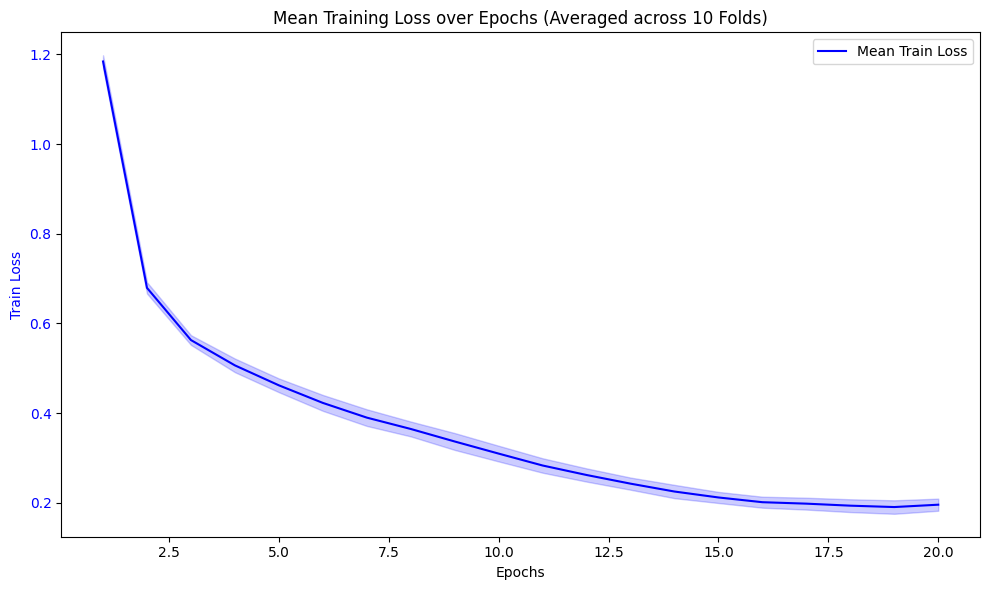

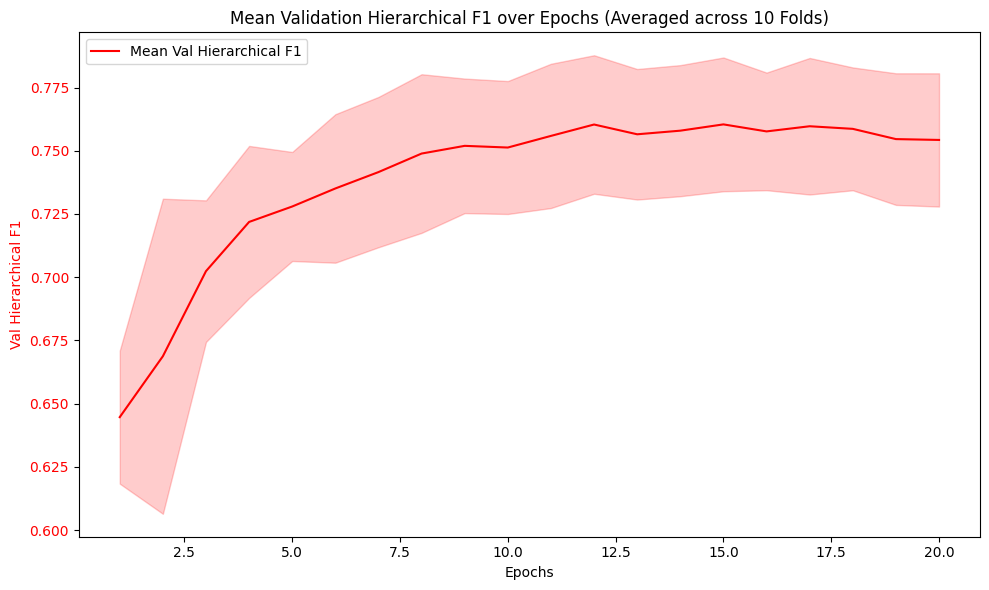

In [15]:


# ============================================================
# 9. GROUPKFold THEO SUBJECT Ở MỨC SEQUENCE + CV VỚI METRIC CHUẨN
# ============================================================
seq_meta = train_df.groupby("sequence_id").agg(
    subject=("subject", "first"),
    y_multi=("y_multi", "first"),
    y_bin=("y_bin", "first")
).reset_index()

BEST_MODEL_PATH = "models/best_model_1.pt"

os.makedirs("models/", exist_ok=True)

# Biến theo dõi
best_hier_f1 = 0.0
best_model_state = None


seq_ids  = seq_meta["sequence_id"].values
subjects = seq_meta["subject"].values

gkf = GroupKFold(n_splits=10)
fold_scores = []
all_fold_train_losses = []  # List of lists: mỗi fold có list train losses qua epochs
all_fold_val_f1s = []       # List of lists: mỗi fold có list val F1 qua epochs

for fold, (tr_idx, val_idx) in enumerate(gkf.split(seq_ids, groups=subjects), start=1):
    print(f"\n========== FOLD {fold} ==========")
    train_seq_ids = seq_ids[tr_idx]
    val_seq_ids   = seq_ids[val_idx]

    fold_train_df = train_df[train_df["sequence_id"].isin(train_seq_ids)].copy()
    fold_val_df   = train_df[train_df["sequence_id"].isin(val_seq_ids)].copy()

    print("  #seq train:", fold_train_df["sequence_id"].nunique(),
          "- #seq val:", fold_val_df["sequence_id"].nunique())

    y_multi_train = seq_meta.iloc[tr_idx]["y_multi"].values
    class_counts  = np.bincount(y_multi_train, minlength=num_classes).astype(np.float32)
    class_weights = 1.0 / (class_counts + 1e-3)
    class_weights = class_weights / class_weights.mean()
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

    y_bin_train = seq_meta.iloc[tr_idx]["y_bin"].values
    pos_count = y_bin_train.sum()
    neg_count = len(y_bin_train) - pos_count
    if pos_count == 0 or neg_count == 0:
        pos_weight_val = 1.0
    else:
        pos_weight_val = neg_count / max(pos_count, 1)
    pos_weight_t = torch.tensor(pos_weight_val, dtype=torch.float32, device=device)

    train_dataset = MultiSensorDataset(
        fold_train_df,
        is_train=True,
        augment=True,
        tof_mask_prob=0.1,
        mixup_prob=0.3,
    )
    val_dataset   = MultiSensorDataset(
        fold_val_df,
        is_train=True,
        augment=False,
        tof_mask_prob=0.0,
        mixup_prob=0.0,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        collate_fn=multisensor_collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        collate_fn=multisensor_collate_fn
    )

    model = MultiSensorBFRBModel(
        imu_in_channels=len(IMU_FEATURE_COLS),
        tof_in_channels=len(TOF_FEATURE_COLS),
        thm_in_channels=len(THM_FEATURE_COLS),
        gru_hidden=160,
        num_classes=num_classes,
        dropout_p=0.3,
        sensor_dropout_p=0.3,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    EPOCHS = 20
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    criterion_bin   = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)
    criterion_multi = FocalLossMultiClass(alpha=class_weights_t, gamma=2.0)

    best_metric = -1.0
    best_state = None

    train_losses = []
    val_f1s = []

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEPOCH {epoch}/{EPOCHS}")
    
        # Train
        train_loss = train_one_epoch(
            model, train_loader, optimizer,
            criterion_bin, criterion_multi,
            lambda_bin=0.3, lambda_multi=1.0,
            max_grad_norm=5.0
        )
        
        # Scheduler step
        scheduler.step()
    
        # Eval trên validation
        model.eval()
        all_true_gestures = []
        all_pred_gestures = []
        
        with torch.no_grad():
            for x_imu, x_tof, x_thm, y_bin, y_multi, subj, seq in val_loader:
                x_imu  = x_imu.to(device)
                x_tof  = x_tof.to(device)
                x_thm  = x_thm.to(device)
    
                _, logits_multi = model(x_imu, x_tof, x_thm)
                preds = torch.argmax(logits_multi, dim=1).cpu().numpy()
                true = y_multi.cpu().numpy()
    
                for t, p in zip(true, preds):
                    all_true_gestures.append(idx2gesture[t])
                    all_pred_gestures.append(idx2gesture[p])
    
        # Tính Hierarchical F1
        current_hier_f1 = hierarchical_f1_from_labels(all_true_gestures, all_pred_gestures)
        # Sau khi tính current_hier_f1
        print(f"Epoch {epoch:02d} | Train loss: {train_loss:.4f} | Val Hierarchical F1: {current_hier_f1:.5f}")

        train_losses.append(train_loss)
        val_f1s.append(current_hier_f1)
        # LƯU MODEL NẾU TỐT HƠN
        if current_hier_f1 > best_hier_f1:
            best_hier_f1 = current_hier_f1
            best_model_state = deepcopy(model.state_dict())
            torch.save(best_model_state, BEST_MODEL_PATH)
            print(f"NEW BEST MODEL! Hierarchical F1 = {best_hier_f1:.5f} -> Đã lưu tại {BEST_MODEL_PATH}")
    
        # In ra top 3 gesture dễ nhầm (tùy chọn)
        # from sklearn.metrics import classification_report
        # print(classification_report(all_true_gestures, all_pred_gestures))
    all_fold_train_losses.append(train_losses)
    all_fold_val_f1s.append(val_f1s)


print(f"\nTraining hoàn tất!")
print(f"Best Hierarchical F1: {best_hier_f1:.5f}")
print(f"Model tốt nhất đã được lưu tại: {BEST_MODEL_PATH}")


epochs = range(1, EPOCHS + 1)
mean_train_losses = np.mean(all_fold_train_losses, axis=0)
mean_val_f1s = np.mean(all_fold_val_f1s, axis=0)
std_train_losses = np.std(all_fold_train_losses, axis=0)
std_val_f1s = np.std(all_fold_val_f1s, axis=0)

# Plot 1: Mean Train Loss over Epochs
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(epochs, mean_train_losses, 'b-', label='Mean Train Loss')
ax1.fill_between(epochs, mean_train_losses - std_train_losses, mean_train_losses + std_train_losses, color='b', alpha=0.2)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Train Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title('Mean Training Loss over Epochs (Averaged across 10 Folds)')
ax1.legend()
fig1.tight_layout()
plt.show()  # Hoặc plt.savefig('train_loss_plot.png')

# Plot 2: Mean Val Hierarchical F1 over Epochs
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(epochs, mean_val_f1s, 'r-', label='Mean Val Hierarchical F1')
ax2.fill_between(epochs, mean_val_f1s - std_val_f1s, mean_val_f1s + std_val_f1s, color='r', alpha=0.2)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Val Hierarchical F1', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_title('Mean Validation Hierarchical F1 over Epochs (Averaged across 10 Folds)')
ax2.legend()
fig2.tight_layout()
plt.show()  # Hoặc plt.savefig('val_f1_plot.png')


In [11]:
# Hardcode idx2gesture từ code gốc
TARGET_GESTURES = [
    'Above ear - pull hair',
    'Cheek - pinch skin',
    'Eyebrow - pull hair',
    'Eyelash - pull hair',
    'Forehead - pull hairline',
    'Forehead - scratch',
    'Neck - pinch skin',
    'Neck - scratch',
]

NON_TARGET_GESTURES = [
    'Write name on leg',
    'Wave hello',
    'Glasses on/off',
    'Text on phone',
    'Write name in air',
    'Feel around in tray and pull out an object',
    'Scratch knee/leg skin',
    'Pull air toward your face',
    'Drink from bottle/cup',
    'Pinch knee/leg skin',
]

ALL_GESTURES = sorted(TARGET_GESTURES + NON_TARGET_GESTURES)
IDX2GESTURE = {i: g for i, g in enumerate(ALL_GESTURES)}

In [12]:
# ============================================================
# LOAD MODEL TỐT NHẤT (Hierarchical F1 cao nhất) ĐỂ INFERENCE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MultiSensorBFRBModel(
        imu_in_channels=len(IMU_FEATURE_COLS),
        tof_in_channels=len(TOF_FEATURE_COLS),
        thm_in_channels=len(THM_FEATURE_COLS),
        gru_hidden=160,
        num_classes=num_classes,
        dropout_p=0.3,
        sensor_dropout_p=0.3,
    ).to(device)

import torch
import os
BEST_MODEL_PATH ="/kaggle/input/ver50-81/pytorch/default/1/best_model_10.81.pt"
#BEST_MODEL_PATH ="/kaggle/working/models/best_model_1.pt"
if os.path.exists(BEST_MODEL_PATH):
    #print(f"Đang load model tốt nhất với Hierarchical F1 = {best_hier_f1:.5f}...")
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    print("Load model thành công!")
else:
    print("Không tìm thấy model đã lưu! Dùng model hiện tại.")

Load model thành công!


In [13]:

def predict_sequence(sequence_df: pd.DataFrame, model: nn.Module, device='cuda') -> str:
    TOF_COLS = [c for c in sequence_df.columns if c.startswith('tof_')]
    THM_COLS = [c for c in sequence_df.columns if c.startswith('thm_')]
    
    processed_df = preprocess_sequence_multisensor(sequence_df)

    x_imu = processed_df[IMU_FEATURE_NAMES].values.astype(np.float32)
    if len(TOF_COLS) > 0:
        x_tof = processed_df[TOF_COLS].values.astype(np.float32)
    else:
        x_tof = np.zeros((len(processed_df), 1), dtype=np.float32)

    if len(THM_COLS) > 0:
        x_thm = processed_df[THM_COLS].values.astype(np.float32)
    else:
        x_thm = np.zeros((len(processed_df), 1), dtype=np.float32)

    x_imu_t = torch.tensor(x_imu, dtype=torch.float32, device=device).unsqueeze(0)
    x_tof_t = torch.tensor(x_tof, dtype=torch.float32, device=device).unsqueeze(0)
    x_thm_t = torch.tensor(x_thm, dtype=torch.float32, device=device).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        logits_bin, logits_multi = model(x_imu_t, x_tof_t, x_thm_t)
        predicted = torch.argmax(logits_multi, dim=1).item()

    predicted_gesture = IDX2GESTURE.get(predicted, 'Text on phone')

    return predicted_gesture

In [14]:
def preprocess_sequence_multisensor_test(grp: pd.DataFrame) -> pd.DataFrame:
    grp = grp.sort_values("sequence_counter").reset_index(drop=True)

    grp[IMU_BASE_COLS] = grp[IMU_BASE_COLS].ffill().bfill()

    acc_np = grp[["acc_x","acc_y","acc_z"]].values.astype(np.float32)
    rot_np = grp[["rot_x","rot_y","rot_z","rot_w"]].values.astype(np.float32)
    handed = grp["handedness"].fillna(1).values.astype(np.float32)

    imu_data_np = np.concatenate([acc_np, rot_np, handed.reshape(-1,1)], axis=1)
    imu_feat_np = make_imu_features_from_np(imu_data_np)

    for i, c in enumerate(IMU_FEATURE_NAMES):
        grp[c] = imu_feat_np[:, i]

    if len(TOF_COLS) > 0:
        tof_vals = grp[TOF_COLS].values.astype(np.float32)
        max_val = 254.0
        mask_neg1 = (tof_vals == -1)
        tof_vals[mask_neg1] = max_val
        tof_vals = tof_vals / max_val
        tof_vals = np.nan_to_num(tof_vals, nan=0.0)
        grp[TOF_COLS] = tof_vals

    if len(THM_COLS) > 0:
        grp[THM_COLS] = grp[THM_COLS].ffill().bfill()
        grp[THM_COLS] = grp[THM_COLS].fillna(method="ffill").fillna(method="bfill").fillna(0)

    eps = 1e-6

    imu_cols = IMU_FEATURE_NAMES
    for c in imu_cols:
        mu  = grp[c].mean()
        std = grp[c].std()
        if std < eps:
            std = eps
        grp[c] = (grp[c] - mu) / std

    if len(TOF_COLS) > 0:
        for c in TOF_COLS:
            mu  = grp[c].mean()
            std = grp[c].std()
            if std < eps:
                std = eps
            grp[c] = (grp[c] - mu) / std

    if len(THM_COLS) > 0:
        for c in THM_COLS:
            mu  = grp[c].mean()
            std = grp[c].std()
            if std < eps:
                std = eps
            grp[c] = (grp[c] - mu) / std

    grp[imu_cols] = grp[imu_cols].ffill().bfill().fillna(0)
    if len(TOF_COLS) > 0:
        grp[TOF_COLS] = grp[TOF_COLS].ffill().bfill().fillna(0)
    if len(THM_COLS) > 0:
        grp[THM_COLS] = grp[THM_COLS].ffill().bfill().fillna(0)

    return grp

In [15]:
def predict_sequence(sequence_df: pd.DataFrame, model: nn.Module, device='cuda') -> str:
    TOF_COLS = [c for c in sequence_df.columns if c.startswith('tof_')]
    THM_COLS = [c for c in sequence_df.columns if c.startswith('thm_')]
    
    processed_df = preprocess_sequence_multisensor_test(sequence_df)

    x_imu = processed_df[IMU_FEATURE_NAMES].values.astype(np.float32)
    if len(TOF_COLS) > 0:
        x_tof = processed_df[TOF_COLS].values.astype(np.float32)
    else:
        x_tof = np.zeros((len(processed_df), 1), dtype=np.float32)

    if len(THM_COLS) > 0:
        x_thm = processed_df[THM_COLS].values.astype(np.float32)
    else:
        x_thm = np.zeros((len(processed_df), 1), dtype=np.float32)

    x_imu_t = torch.tensor(x_imu, dtype=torch.float32, device=device).unsqueeze(0)
    x_tof_t = torch.tensor(x_tof, dtype=torch.float32, device=device).unsqueeze(0)
    x_thm_t = torch.tensor(x_thm, dtype=torch.float32, device=device).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        logits_bin, logits_multi = model(x_imu_t, x_tof_t, x_thm_t)
        predicted = torch.argmax(logits_multi, dim=1).item()

    predicted_gesture = IDX2GESTURE.get(predicted, 'Text on phone')

    return predicted_gesture

In [16]:
def predict(sequence: pl.DataFrame, demographics: pl.DataFrame) -> str:
    sequence_pd = sequence.to_pandas()
    demographics_pd = demographics.to_pandas()

    subject = sequence_pd['subject'].iloc[0] if 'subject' in sequence_pd.columns else None
    if subject is not None:
        handedness_row = demographics_pd[demographics_pd['subject'] == subject]
        if not handedness_row.empty:
            handedness = handedness_row['handedness'].iloc[0] if 'handedness' in handedness_row.columns else 1.0
            sequence_pd['handedness'] = handedness
    
    predicted_gesture = predict_sequence(sequence_pd, model, device)

    return predicted_gesture

In [17]:
import kaggle_evaluation.cmi_inference_server

inference_server = kaggle_evaluation.cmi_inference_server.CMIInferenceServer(predict)

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    inference_server.serve()
else:
    inference_server.run_local_gateway(
        data_paths=(
            '/kaggle/input/cmi-detect-behavior-with-sensor-data/test.csv',
            '/kaggle/input/cmi-detect-behavior-with-sensor-data/test_demographics.csv',
        )
    )
